<a href="https://colab.research.google.com/github/mbilalerkoc/Medical-Image-Segmentation-System/blob/main/Kidney_U_Net%2B%2B_E%C4%9Fitim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Kurulum ve Veri Seti Yükleme

In [2]:
# 1. HÜCRE: KURULUM VE VERİ YÜKLEME
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from google.colab import drive

print("⏳ Google Drive bağlanıyor...")
drive.mount('/content/drive')

# --- KONFİGÜRASYON ---
IMG_SIZE = 256
BATCH_SIZE = 16
EPOCHS = 75
LEARNING_RATE = 1e-3
TEST_ORANI = 0.15
VAL_ORANI = 0.15
RANDOM_SEED = 42

# --- ANA DİZİNLER ---
DRIVE_BASE = '/content/drive/MyDrive/Medical-Image-Segmentation-System'
CIKARTILACAK_YER = '/content'

KIDNEY_ENGINE_DIR = f'{DRIVE_BASE}/ai_engine_kidney'
MODEL_KAYIT        = f'{KIDNEY_ENGINE_DIR}/saved_models'
SONUC_KLASOR       = f'{KIDNEY_ENGINE_DIR}/results'
PROCESSED_DATA_DIR = f'{KIDNEY_ENGINE_DIR}/processed_data'

for p in [MODEL_KAYIT, SONUC_KLASOR, PROCESSED_DATA_DIR]:
    os.makedirs(p, exist_ok=True)

MODEL_EN_IYI_YOL = f"{MODEL_KAYIT}/20.19_bobrek_unetplusplus_en_iyi.h5"
MODEL_FINAL_YOL  = f"{MODEL_KAYIT}/20.19_bobrek_unetplusplus_final.h5"
NPY_X_YOL = f"{PROCESSED_DATA_DIR}/20.19_bobrek_v2_X.npy"
NPY_Y_YOL = f"{PROCESSED_DATA_DIR}/20.19_bobrek_v2_Y.npy"
GRAFIK_YOL = f"{SONUC_KLASOR}/20.19_egitim_grafikleri.png"
TAHMIN_YOL = f"{SONUC_KLASOR}/20.19_ornek_tahminler.png"
METRIK_YOL = f"{SONUC_KLASOR}/20.19_test_metrikleri.txt"

# --- ZİP ÇIKARMA VE KLASÖR BULMA ---
zip_yolu = f'{DRIVE_BASE}/dataset/archive.zip'
print("\n⏳ archive.zip doğrudan ana dizine (/content) çıkarılıyor...")
!unzip -q -o "{zip_yolu}" -d "{CIKARTILACAK_YER}"
print("⚡ Zip çıkarma işlemi tamamlandı!")

IMG_DIR, MASK_DIR = None, None
for root, dirs, files in os.walk(CIKARTILACAK_YER):
    if 'drive' in root: continue
    for d in dirs:
        if d.lower() in ['images', 'image']: IMG_DIR = os.path.join(root, d)
        if d.lower() in ['masks', 'mask','label']: MASK_DIR = os.path.join(root, d)

if IMG_DIR and MASK_DIR:
    print(f"✅ Klasörler Başarıyla Bulundu:\n📸 Resimler: {IMG_DIR}\n🎭 Maskeler: {MASK_DIR}")
else:
    raise FileNotFoundError("❌ HATA: Çıkarılan dosyalar arasında resim veya maske klasörü bulunamadı!")

⏳ Google Drive bağlanıyor...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

⏳ archive.zip doğrudan ana dizine (/content) çıkarılıyor...
⚡ Zip çıkarma işlemi tamamlandı!
✅ Klasörler Başarıyla Bulundu:
📸 Resimler: /content/data/image
🎭 Maskeler: /content/data/label


Veri Seti İncelenmesi

📊 Veri Seti Bilgisi:
Toplam Bulunan Ham Görüntü: 838 adet


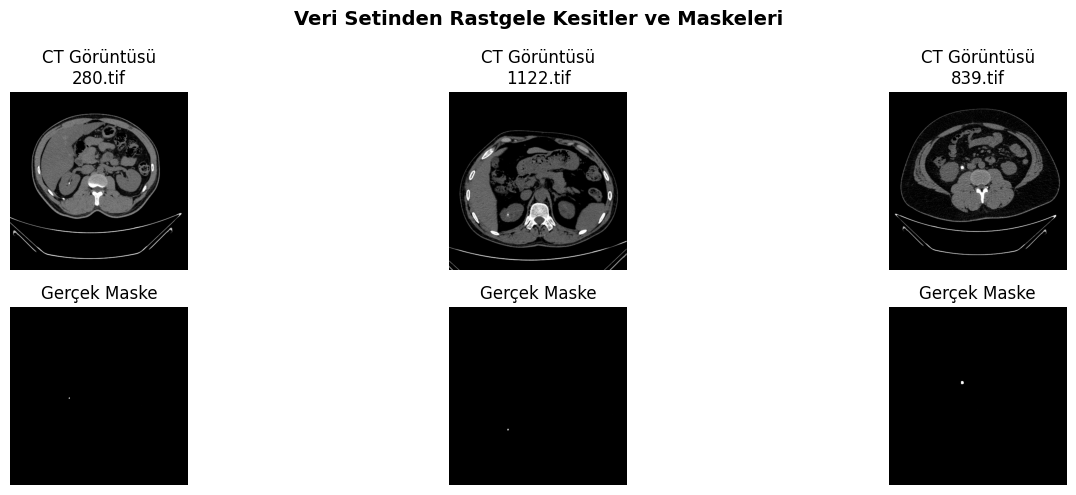

In [3]:
# 2. HÜCRE: VERİ SETİ İNCELEMESİ VE GÖRSELLEŞTİRME
resim_dosyalari = sorted([f for f in os.listdir(IMG_DIR) if f.lower().endswith(('.jpg', '.png', '.tif', '.jpeg'))])
print(f"📊 Veri Seti Bilgisi:")
print(f"Toplam Bulunan Ham Görüntü: {len(resim_dosyalari)} adet")

# Rastgele 3 görüntü seçip ekrana bastıralım
rastgele_secim = random.sample(resim_dosyalari, min(3, len(resim_dosyalari)))

plt.figure(figsize=(15, 5))
plt.suptitle("Veri Setinden Rastgele Kesitler ve Maskeleri", fontsize=14, fontweight='bold')

for i, f_name in enumerate(rastgele_secim):
    stem = os.path.splitext(f_name)[0]

    # Maske adını bul (farklı formatları destekler)
    olasi_maskeler = [f"{stem}.png", f"{stem}.tif", f"{stem}_mask.png", f"{stem}_mask.tif"]
    maske_yolu = None
    for m_ad in olasi_maskeler:
        if os.path.exists(os.path.join(MASK_DIR, m_ad)):
            maske_yolu = os.path.join(MASK_DIR, m_ad)
            break

    img = cv2.imread(os.path.join(IMG_DIR, f_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Ekranda düzgün renk için

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"CT Görüntüsü\n{f_name}")
    plt.axis('off')

    if maske_yolu:
        mask = cv2.imread(maske_yolu, cv2.IMREAD_GRAYSCALE)
        plt.subplot(2, 3, i + 4)
        plt.imshow(mask, cmap='gray')
        plt.title("Gerçek Maske")
        plt.axis('off')
    else:
        plt.subplot(2, 3, i + 4)
        plt.title("Maske Bulunamadı!")
        plt.axis('off')

plt.tight_layout()
plt.show()

Veri Seti İşlemleri

In [4]:
# 3. HÜCRE: ÖN İŞLEME VE VERİ JENERATÖRLERİ
def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    lab = cv2.merge((l, a, b))
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

def preprocess(img_path, mask_path):
    img = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if img is None or mask is None: return None, None
    img = apply_clahe(img)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
    _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    mask = mask.astype(np.float32) / 255.0
    if len(mask.shape) == 2: mask = np.expand_dims(mask, axis=-1)
    return img, mask

def augment(img, mask):
    if np.random.rand() > 0.5:
        img, mask = cv2.flip(img, 1), cv2.flip(mask, 1)
    if np.random.rand() > 0.7:
        img, mask = cv2.flip(img, 0), cv2.flip(mask, 0)
    if np.random.rand() > 0.7:
        angle = np.random.uniform(-10, 10)
        h, w = img.shape[:2]
        M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
        img = cv2.warpAffine(img, M, (w, h))
        mask = cv2.warpAffine(mask, M, (w, h), flags=cv2.INTER_NEAREST)
    if len(mask.shape) == 2: mask = np.expand_dims(mask, axis=-1)
    return img, mask

def veri_yukle_ve_ayir():
    img_paths, mask_paths = [], []
    resim_listesi = sorted([f for f in os.listdir(IMG_DIR) if f.lower().endswith(('.jpg', '.png', '.tif', '.jpeg'))])

    for f in resim_listesi:
        stem = os.path.splitext(f)[0]
        olasi_maskeler = [f"{stem}.png", f"{stem}.tif", f"{stem}_mask.png", f"{stem}_mask.tif"]
        for m_ad in olasi_maskeler:
            if os.path.exists(os.path.join(MASK_DIR, m_ad)):
                img_paths.append(os.path.join(IMG_DIR, f))
                mask_paths.append(os.path.join(MASK_DIR, m_ad))
                break

    X_temp, X_test, y_temp, y_test = train_test_split(img_paths, mask_paths, test_size=TEST_ORANI, random_state=RANDOM_SEED)
    val_oran_hesabi = VAL_ORANI / (1.0 - TEST_ORANI)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_oran_hesabi, random_state=RANDOM_SEED)

    print(f"✅ Dağılım -> Eğitim: {len(X_train)} | Validasyon: {len(X_val)} | Test: {len(X_test)}")
    return X_train, X_val, X_test, y_train, y_val, y_test

def test_verilerini_npy_kaydet(X_test_paths, y_test_paths):
    print("📦 Test verileri VS Code (.npy) için işleniyor...")
    X_test_islenmis, y_test_islenmis = [], []
    for x_p, y_p in zip(X_test_paths, y_test_paths):
        img, mask = preprocess(x_p, y_p)
        if img is not None:
            X_test_islenmis.append(img)
            y_test_islenmis.append(mask)

    X_np, Y_np = np.array(X_test_islenmis, dtype=np.float32), np.array(y_test_islenmis, dtype=np.float32)
    np.save(NPY_X_YOL, X_np)
    np.save(NPY_Y_YOL, Y_np)
    print(f"✅ Test verileri Drive'a kaydedildi.")
    return X_np, Y_np

class DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, img_paths, mask_paths, batch_size, is_train=True):
        self.img_paths, self.mask_paths = np.array(img_paths), np.array(mask_paths)
        self.batch_size, self.is_train = batch_size, is_train
    def __len__(self): return int(np.ceil(len(self.img_paths) / float(self.batch_size)))
    def __getitem__(self, idx):
        batch_x = self.img_paths[idx * self.batch_size : (idx + 1) * self.batch_size]
        batch_y = self.mask_paths[idx * self.batch_size : (idx + 1) * self.batch_size]
        X, Y = [], []
        for x_p, y_p in zip(batch_x, batch_y):
            img, mask = preprocess(x_p, y_p)
            if img is not None:
                if self.is_train and np.random.rand() > 0.5: img, mask = augment(img.copy(), mask.copy())
                X.append(img)
                Y.append(mask)
        return np.array(X), np.array(Y)
    def on_epoch_end(self):
        if self.is_train:
            indices = np.arange(len(self.img_paths))
            np.random.shuffle(indices)
            self.img_paths, self.mask_paths = self.img_paths[indices], self.mask_paths[indices]

# Jeneratörleri Başlat
X_train_p, X_val_p, X_test_p, y_train_p, y_val_p, y_test_p = veri_yukle_ve_ayir()
X_test_npy, y_test_npy = test_verilerini_npy_kaydet(X_test_p, y_test_p)

train_generator = DataGenerator(X_train_p, y_train_p, BATCH_SIZE, is_train=True)
val_generator = DataGenerator(X_val_p, y_val_p, BATCH_SIZE, is_train=False)
test_generator = DataGenerator(X_test_p, y_test_p, BATCH_SIZE, is_train=False)

✅ Dağılım -> Eğitim: 586 | Validasyon: 126 | Test: 126
📦 Test verileri VS Code (.npy) için işleniyor...
✅ Test verileri Drive'a kaydedildi.


Model ve Eğitim

In [5]:
# 4. HÜCRE: MODEL MİMARİSİ, EĞİTİM VE DEĞERLENDİRME
def dice_katsayisi(y_gercek, y_tahmin):
    y_gercek_duz = tf.reshape(y_gercek, [-1])
    y_tahmin_duz = tf.reshape(y_tahmin, [-1])
    kesisim = tf.reduce_sum(y_gercek_duz * y_tahmin_duz)
    return (2. * kesisim + 1e-5) / (tf.reduce_sum(y_gercek_duz) + tf.reduce_sum(y_tahmin_duz) + 1e-5)

def dice_loss(y_gercek, y_tahmin): return 1.0 - dice_katsayisi(y_gercek, y_tahmin)

def agirlikli_birlesik_loss(y_gercek, y_tahmin):
    bce = tf.keras.losses.binary_crossentropy(y_gercek, y_tahmin)
    return (0.7 * bce) + (0.3 * dice_loss(y_gercek, y_tahmin))

def conv_block(x, filters):
    x = layers.Conv2D(filters, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    return x

def unet_plus_plus_modeli_kur(giris_boyutu=(IMG_SIZE, IMG_SIZE, 3)):
    girdiler = Input(giris_boyutu)
    x0_0 = conv_block(girdiler, 32)
    p1 = layers.MaxPooling2D((2, 2))(x0_0)
    x1_0 = conv_block(p1, 64)
    p2 = layers.MaxPooling2D((2, 2))(x1_0)
    x2_0 = conv_block(p2, 128)
    p3 = layers.MaxPooling2D((2, 2))(x2_0)
    x3_0 = conv_block(p3, 256)
    p4 = layers.MaxPooling2D((2, 2))(x3_0)
    x4_0 = conv_block(p4, 512)

    x0_1 = conv_block(layers.concatenate([x0_0, layers.UpSampling2D((2, 2))(x1_0)]), 32)
    x1_1 = conv_block(layers.concatenate([x1_0, layers.UpSampling2D((2, 2))(x2_0)]), 64)
    x2_1 = conv_block(layers.concatenate([x2_0, layers.UpSampling2D((2, 2))(x3_0)]), 128)
    x3_1 = conv_block(layers.concatenate([x3_0, layers.UpSampling2D((2, 2))(x4_0)]), 256)

    x0_2 = conv_block(layers.concatenate([x0_0, x0_1, layers.UpSampling2D((2, 2))(x1_1)]), 32)
    x1_2 = conv_block(layers.concatenate([x1_0, x1_1, layers.UpSampling2D((2, 2))(x2_1)]), 64)
    x2_2 = conv_block(layers.concatenate([x2_0, x2_1, layers.UpSampling2D((2, 2))(x3_1)]), 128)

    x0_3 = conv_block(layers.concatenate([x0_0, x0_1, x0_2, layers.UpSampling2D((2, 2))(x1_2)]), 32)
    x1_3 = conv_block(layers.concatenate([x1_0, x1_1, x1_2, layers.UpSampling2D((2, 2))(x2_2)]), 64)

    c0_4 = conv_block(layers.concatenate([x0_0, x0_1, x0_2, x0_3, layers.UpSampling2D((2, 2))(x1_3)]), 32)
    cikti = layers.Conv2D(1, (1, 1), activation='sigmoid')(c0_4)

    model = models.Model(inputs=girdiler, outputs=cikti)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                  loss=agirlikli_birlesik_loss, metrics=['accuracy', dice_katsayisi])
    return model

def sonuclari_degerlendir_ve_kaydet(model, test_generator, history):
    print("\n📊 Değerlendirme Aşaması Başlıyor...")
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Eğitim Loss', color='#22c55e')
    plt.plot(history.history['val_loss'], label='Doğrulama Loss', color='#ef4444')
    plt.title('Böbrek Taşı - Model Kayıp (Loss) Eğrisi')
    plt.legend()
    if 'dice_katsayisi' in history.history:
        plt.subplot(1, 2, 2)
        plt.plot(history.history['dice_katsayisi'], label='Eğitim Dice', color='#3b82f6')
        plt.plot(history.history['val_dice_katsayisi'], label='Doğrulama Dice', color='#f59e0b')
        plt.title('Böbrek Taşı - Segmentasyon Başarısı (Dice)')
        plt.legend()
    plt.tight_layout()
    plt.savefig(GRAFIK_YOL)
    plt.close()

    TP = FP = FN = 0
    esik = 0.80
    for i in range(len(test_generator)):
        X_batch, y_batch = test_generator[i]
        tahminler = model.predict(X_batch, verbose=0)
        tahmin_binary, gercek = (tahminler > esik).astype(np.float32), y_batch.astype(np.float32)
        TP += np.sum(tahmin_binary * gercek)
        FP += np.sum(tahmin_binary * (1 - gercek))
        FN += np.sum((1 - tahmin_binary) * gercek)

    precision, recall = TP / (TP + FP + 1e-7), TP / (TP + FN + 1e-7)
    iou = TP / (TP + FP + FN + 1e-7)
    test_sonuclari = model.evaluate(test_generator, verbose=0)
    test_dice = test_sonuclari[2] if len(test_sonuclari) > 2 else 0.0

    sonuc_metni = f"""
╔══════════════════════════════════════════╗
║     BÖBREK TAŞI (U-NET++) SONUÇLARI      ║
╠══════════════════════════════════════════╣
║  Dice Score: {test_dice:.4f}                     ║
║  IoU       : {iou:.4f}                     ║
║  Precision : {precision:.4f}                     ║
║  Recall    : {recall:.4f}                     ║
║  Loss      : {test_sonuclari[0]:.4f}                     ║
╚══════════════════════════════════════════╝"""
    print(sonuc_metni)
    with open(METRIK_YOL, 'w', encoding='utf-8') as f: f.write(sonuc_metni)
    print(f"✅ Analizler Drive'a Kaydedildi!")

print("\n" + "="*60 + "\n 🚀 BÖBREK TAŞI (U-NET++) EĞİTİMİ BAŞLIYOR\n" + "="*60)
model = unet_plus_plus_modeli_kur()
callbacks = [
    ModelCheckpoint(MODEL_EN_IYI_YOL, monitor='val_loss', save_best_only=True, mode='min', verbose=1),
    EarlyStopping(monitor='val_loss', patience=20, mode='min', restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=1)
]
history = model.fit(train_generator, validation_data=val_generator, epochs=EPOCHS, callbacks=callbacks)
model.save(MODEL_FINAL_YOL)
sonuclari_degerlendir_ve_kaydet(model, test_generator, history)


 🚀 BÖBREK TAŞI (U-NET++) EĞİTİMİ BAŞLIYOR


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/75
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 973ms/step - accuracy: 0.6708 - dice_katsayisi: 0.0015 - loss: 0.7943
Epoch 1: val_loss improved from None to 0.66890, saving model to /content/drive/MyDrive/Medical-Image-Segmentation-System/ai_engine_kidney/saved_models/20.19_bobrek_unetplusplus_en_iyi.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Medical-Image-Segmentation-System/ai_engine_kidney/saved_models/20.19_bobrek_unetplusplus_en_iyi.h5
37/37 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.8315 - dice_katsayisi: 0.0015 - loss: 0.7527 - val_accuracy: 0.9790 - val_dice_katsayisi: 0.0013 - val_loss: 0.6689 - learning_rate: 0.0010
Epoch 2/75
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9967 - dice_katsayisi: 0.0016 - loss: 0.6802
Epoch 2: val_loss improved from 0.66890 to 0.54562, saving model to /content/drive/MyDrive/Medical-Image-Segmentation-System/ai_engine_kidney/saved_models/20.19_bobrek_unetplusplus_en_iyi.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Medical-Image-Segmentation-System/ai_engine_kidney/saved_models/20.19_bobrek_unetplusplus_en_iyi.h5
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 155ms/step - accuracy: 0.9982 - dice_katsayisi: 0.0016 - loss: 0.6585 - val_accuracy: 0.9994 - val_dice_katsayisi: 0.0014 - val_loss: 0.5456 - learning_rate: 0.0010
Epoch 3/75
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9994 - dice_katsayisi: 0.0020 - loss: 0.5874
Epoch 3: val_loss improved from 0.54562 to 0.50153, saving model to /content/drive/MyDrive/Medical-Image-Segmentation-System/ai_engine_kidney/saved_models/20.19_bobrek_unetplusplus_en_iyi.h5


...


Epoch 46: finished saving model to /content/drive/MyDrive/Medical-Image-Segmentation-System/ai_engine_kidney/saved_models/20.19_bobrek_unetplusplus_en_iyi.h5
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 186ms/step - accuracy: 0.9999 - dice_katsayisi: 0.9312 - loss: 0.0211 - val_accuracy: 0.9999 - val_dice_katsayisi: 0.9394 - val_loss: 0.0186 - learning_rate: 0.0010
Epoch 47/75
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9999 - dice_katsayisi: 0.9360 - loss: 0.0197
Epoch 47: val_loss did not improve from 0.01860
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - accuracy: 0.9999 - dice_katsayisi: 0.9340 - loss: 0.0203 - val_accuracy: 0.9999 - val_dice_katsayisi: 0.9136 - val_loss: 0.0264 - learning_rate: 0.0010
Epoch 48/75
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9999 - dice_katsayisi: 0.9342 - loss: 0.0202
Epoch 48: val_loss did not improve from 0.01860
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step - accuracy: 0.9999 - dice_katsayisi: 0.9351 - loss: 0.0199 - val_accuracy: 0.9999 - val_di


Epoch 54: finished saving model to /content/drive/MyDrive/Medical-Image-Segmentation-System/ai_engine_kidney/saved_models/20.19_bobrek_unetplusplus_en_iyi.h5
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 193ms/step - accuracy: 0.9999 - dice_katsayisi: 0.9369 - loss: 0.0194 - val_accuracy: 0.9999 - val_dice_katsayisi: 0.9402 - val_loss: 0.0183 - learning_rate: 5.0000e-04
Epoch 55/75
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9999 - dice_katsayisi: 0.9324 - loss: 0.0209
Epoch 55: val_loss did not improve from 0.01832
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step - accuracy: 0.9999 - dice_katsayisi: 0.9347 - loss: 0.0201 - val_accuracy: 0.9999 - val_dice_katsayisi: 0.9390 - val_loss: 0.0187 - learning_rate: 5.0000e-04
Epoch 56/75
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9999 - dice_katsayisi: 0.9371 - loss: 0.0193
Epoch 56: val_loss did not improve from 0.01832
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 132ms/step - accuracy: 0.9999 - dice_katsayisi: 0.9369 - loss: 0.0193 - val_accuracy: 0.9999 


Epoch 60: finished saving model to /content/drive/MyDrive/Medical-Image-Segmentation-System/ai_engine_kidney/saved_models/20.19_bobrek_unetplusplus_en_iyi.h5
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 186ms/step - accuracy: 0.9999 - dice_katsayisi: 0.9370 - loss: 0.0194 - val_accuracy: 0.9999 - val_dice_katsayisi: 0.9415 - val_loss: 0.0180 - learning_rate: 5.0000e-04
Epoch 61/75
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9999 - dice_katsayisi: 0.9346 - loss: 0.0201
Epoch 61: val_loss did not improve from 0.01799
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 133ms/step - accuracy: 0.9999 - dice_katsayisi: 0.9381 - loss: 0.0191 - val_accuracy: 0.9999 - val_dice_katsayisi: 0.9309 - val_loss: 0.0213 - learning_rate: 5.0000e-04
Epoch 62/75
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9999 - dice_katsayisi: 0.9379 - loss: 0.0192
Epoch 62: val_loss did not improve from 0.01799
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - accuracy: 0.9999 - dice_katsayisi: 0.9382 - loss: 0.0191 - val_accuracy: 0.9999 


Epoch 69: finished saving model to /content/drive/MyDrive/Medical-Image-Segmentation-System/ai_engine_kidney/saved_models/20.19_bobrek_unetplusplus_en_iyi.h5
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 187ms/step - accuracy: 0.9999 - dice_katsayisi: 0.9430 - loss: 0.0175 - val_accuracy: 0.9999 - val_dice_katsayisi: 0.9426 - val_loss: 0.0177 - learning_rate: 2.5000e-04
Epoch 70/75
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9999 - dice_katsayisi: 0.9449 - loss: 0.0170
Epoch 70: val_loss did not improve from 0.01768
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - accuracy: 0.9999 - dice_katsayisi: 0.9408 - loss: 0.0182 - val_accuracy: 0.9999 - val_dice_katsayisi: 0.9394 - val_loss: 0.0187 - learning_rate: 2.5000e-04
Epoch 71/75
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9999 - dice_katsayisi: 0.9417 - loss: 0.0179
Epoch 71: val_loss did not improve from 0.01768
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 133ms/step - accuracy: 0.9999 - dice_katsayisi: 0.9444 - loss: 0.0172 - val_accuracy: 0.9999 


📊 Değerlendirme Aşaması Başlıyor...

╔══════════════════════════════════════════╗
║     BÖBREK TAŞI (U-NET++) SONUÇLARI      ║
╠══════════════════════════════════════════╣
║  Dice Score: 0.9445                     ║
║  IoU       : 0.9020                     ║
║  Precision : 0.9495                     ║
║  Recall    : 0.9474                     ║
║  Loss      : 0.0170                     ║
╚══════════════════════════════════════════╝
✅ Analizler Drive'a Kaydedildi!


⏳ Google Drive bağlanıyor...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⏳ Model ve Test Verileri Drive'dan yükleniyor...


✅ Yüklendi! Toplam Test Verisi: 126 adet
🎲 Seçilen Test Kesitleri (İndeksler): [ 50  87 112  83  30]


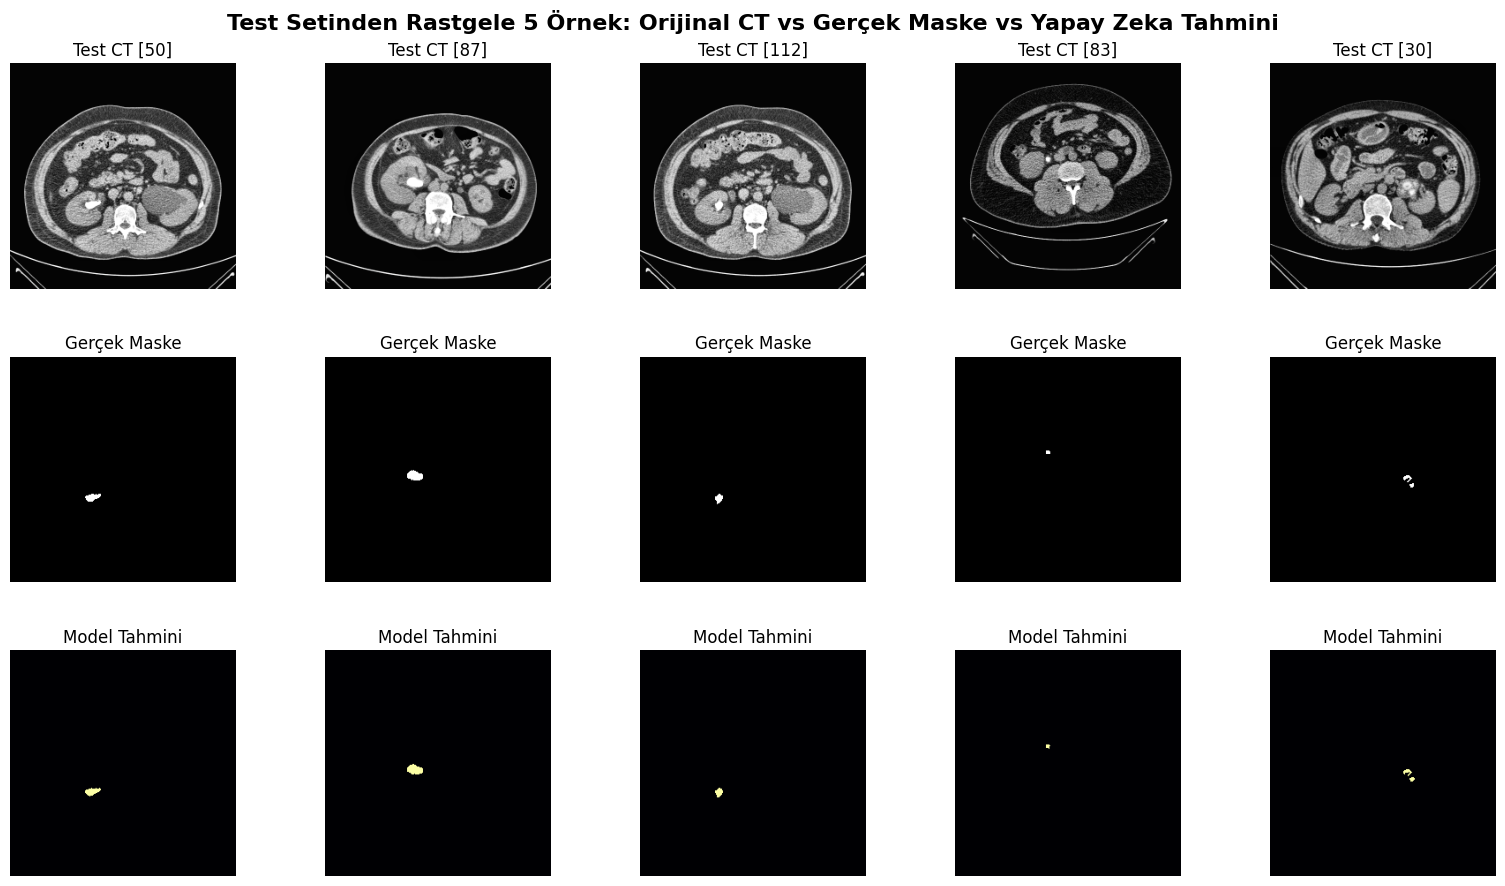

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from google.colab import drive

# 1. GOOGLE DRIVE BAĞLANTISI (Colab için şart)
print("⏳ Google Drive bağlanıyor...")
drive.mount('/content/drive')

# 2. KONTROL MERKEZİ: Colab / Drive Dosya Yolları
DRIVE_BASE = '/content/drive/MyDrive/Medical-Image-Segmentation-System/ai_engine_kidney'
MODEL_YOLU = f"{DRIVE_BASE}/saved_models/20.19_bobrek_unetplusplus_final.h5"
X_TEST_YOLU = f"{DRIVE_BASE}/processed_data/bobrek_U-Net++_X.npy"
Y_TEST_YOLU = f"{DRIVE_BASE}/processed_data/bobrek_U-Net++_Y.npy"
ESIK_DEGERI = 0.80

# Özel Metrikleri Modele Tanıtma Fonksiyonları
def dice_katsayisi(y_gercek, y_tahmin):
    y_gercek_duz = tf.reshape(y_gercek, [-1])
    y_tahmin_duz = tf.reshape(y_tahmin, [-1])
    kesisim = tf.reduce_sum(y_gercek_duz * y_tahmin_duz)
    return (2. * kesisim + 1e-5) / (tf.reduce_sum(y_gercek_duz) + tf.reduce_sum(y_tahmin_duz) + 1e-5)

def dice_loss(y_gercek, y_tahmin):
    return 1.0 - dice_katsayisi(y_gercek, y_tahmin)

def agirlikli_birlesik_loss(y_gercek, y_tahmin):
    bce = tf.keras.losses.binary_crossentropy(y_gercek, y_tahmin)
    return (0.7 * bce) + (0.3 * dice_loss(y_gercek, y_tahmin))

# 3. MODELİ VE TEST VERİLERİNİ YÜKLE
print("⏳ Model ve Test Verileri Drive'dan yükleniyor...")
model = load_model(MODEL_YOLU, custom_objects={'agirlikli_birlesik_loss': agirlikli_birlesik_loss, 'dice_katsayisi': dice_katsayisi})
X_test = np.load(X_TEST_YOLU)
y_test = np.load(Y_TEST_YOLU)
print(f"✅ Yüklendi! Toplam Test Verisi: {len(X_test)} adet")

# 4. İÇİNDE GERÇEKTEN TAŞ OLANLARI BUL VE 5 TANE SEÇ
tasli_idxler = np.where(y_test.max(axis=(1, 2, 3)) > 0)[0]

if len(tasli_idxler) == 0:
    print("❌ HATA: Test setinde hiç taşlı vaka bulunamadı!")
else:
    secilecek_sayi = min(5, len(tasli_idxler))
    secilen_idxler = np.random.choice(tasli_idxler, secilecek_sayi, replace=False)

    print(f"🎲 Seçilen Test Kesitleri (İndeksler): {secilen_idxler}")

    X_ornekler = X_test[secilen_idxler]
    y_gercekler = y_test[secilen_idxler]

    # 5. TAHMİNİ YAP
    tahminler = model.predict(X_ornekler, verbose=0)
    tahminler_binary = (tahminler > ESIK_DEGERI).astype(np.float32)

    # 6. EKRANA ÇİZDİRME (15'li Tablo: 3 Satır x 5 Sütun)
    plt.figure(figsize=(16, 9))
    plt.suptitle("Test Setinden Rastgele 5 Örnek: Orijinal CT vs Gerçek Maske vs Yapay Zeka Tahmini", fontsize=16, fontweight='bold')

    for i in range(secilecek_sayi):
        # 1. Satır: Orijinal Tomografi
        plt.subplot(3, secilecek_sayi, i + 1)
        plt.imshow(X_ornekler[i].squeeze(), cmap='gray')
        plt.title(f"Test CT [{secilen_idxler[i]}]")
        plt.axis('off')

        # 2. Satır: Gerçek Maske (Ground Truth)
        plt.subplot(3, secilecek_sayi, i + 1 + secilecek_sayi)
        plt.imshow(y_gercekler[i].squeeze(), cmap='gray')
        plt.title("Gerçek Maske")
        plt.axis('off')

        # 3. Satır: U-Net++ Tahmini
        plt.subplot(3, secilecek_sayi, i + 1 + 2 * secilecek_sayi)
        plt.imshow(tahminler_binary[i].squeeze(), cmap='inferno')
        plt.title("Model Tahmini")
        plt.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.92, hspace=0.3)
    plt.show()